<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook4_Context_Tree_Weighting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Context Tree Weighting (Educational Approximation)

This notebook introduces ideas inspired by **Context Tree Weighting (CTW)**,
one of the key components used in the MC-AIXI-CTW approximation.

This notebook demonstrates:

- Variable-order context models
- Context trees
- Online probability estimation
- Compression-inspired prediction
- Entropy calculation
- Information gain
- Adaptive learning

> This is an educational implementation. The original CTW algorithm is more
sophisticated and mathematically exact.


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(123)
np.random.seed(123)


## Binary Context Tree

In [2]:
class CTWNode:
    def __init__(self):
        self.zero=0
        self.one=0
        self.children={}

    def update(self,symbol):
        if symbol==0:
            self.zero+=1
        else:
            self.one+=1

    def probability(self):
        # KT estimator
        total=self.zero+self.one
        p0=(self.zero+0.5)/(total+1)
        p1=(self.one+0.5)/(total+1)
        return p0,p1


## Context Tree

In [3]:
class ContextTree:

    def __init__(self,max_depth=4):
        self.max_depth=max_depth
        self.root=CTWNode()

    def _get_node(self,context):
        node=self.root
        for c in context:
            if c not in node.children:
                node.children[c]=CTWNode()
            node=node.children[c]
        return node

    def update(self,history,symbol):
        self.root.update(symbol)

        for d in range(1,self.max_depth+1):
            ctx=tuple(history[-d:]) if len(history)>=d else tuple(history)
            node=self._get_node(ctx)
            node.update(symbol)

    def predict(self,history):
        best=self.root
        depth=min(len(history),self.max_depth)

        for d in range(depth,0,-1):
            ctx=tuple(history[-d:])
            node=self._get_node(ctx)
            if node.zero+node.one>0:
                best=node
                break

        return best.probability()


## Synthetic Sequence Generator

In [4]:
def generate_sequence(n=200):
    seq=[]
    for i in range(n):
        if i<4:
            seq.append(random.randint(0,1))
        else:
            # simple repeating dependency
            if seq[-1]==seq[-3]:
                seq.append(1)
            else:
                seq.append(0)
    return seq

sequence=generate_sequence()
sequence[:20]


[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0]

## Online Learning

In [5]:
tree=ContextTree(max_depth=5)

history=[]
pred0=[]
pred1=[]
entropy=[]

for s in sequence:
    p0,p1=tree.predict(history)
    pred0.append(p0)
    pred1.append(p1)

    h=0
    for p in (p0,p1):
        h -= p*math.log2(p)
    entropy.append(h)

    tree.update(history,s)
    history.append(s)


## Prediction Probabilities

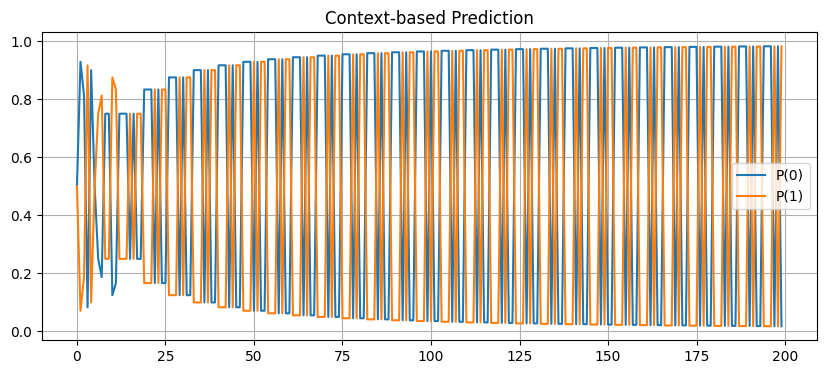

In [6]:
plt.figure(figsize=(10,4))
plt.plot(pred0,label="P(0)")
plt.plot(pred1,label="P(1)")
plt.legend()
plt.grid()
plt.title("Context-based Prediction")
plt.show()


## Entropy

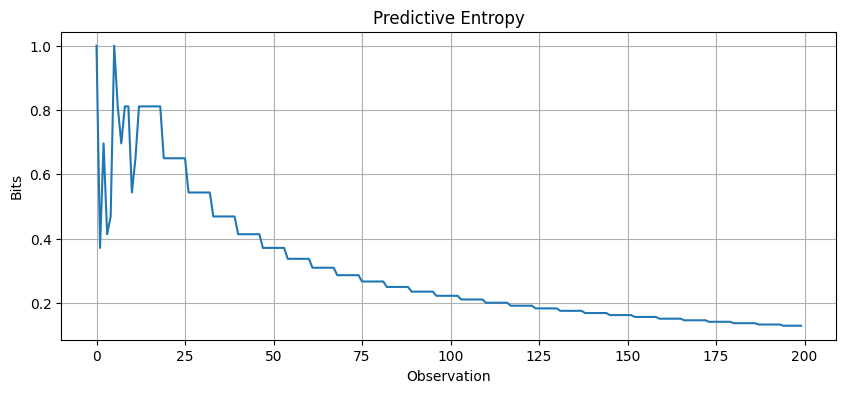

In [7]:
plt.figure(figsize=(10,4))
plt.plot(entropy)
plt.grid()
plt.ylabel("Bits")
plt.xlabel("Observation")
plt.title("Predictive Entropy")
plt.show()


## Information Gain

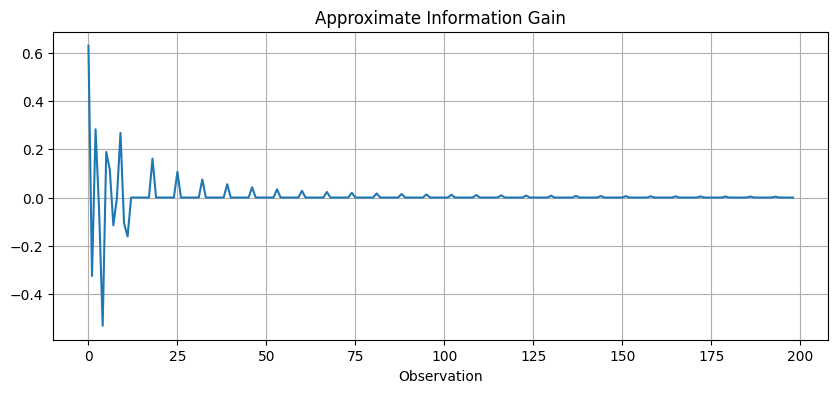

In [8]:
info_gain=[]

for i in range(1,len(entropy)):
    info_gain.append(entropy[i-1]-entropy[i])

plt.figure(figsize=(10,4))
plt.plot(info_gain)
plt.grid()
plt.title("Approximate Information Gain")
plt.xlabel("Observation")
plt.show()


## Adaptive Predictor

In [9]:
history=[]
tree=ContextTree(max_depth=4)

correct=0

for i,s in enumerate(sequence):
    p0,p1=tree.predict(history)
    pred=0 if p0>=p1 else 1
    if pred==s:
        correct+=1
    tree.update(history,s)
    history.append(s)

acc=correct/len(sequence)
print("Prediction accuracy:",round(acc,3))


Prediction accuracy: 0.975


## Context Depth Comparison

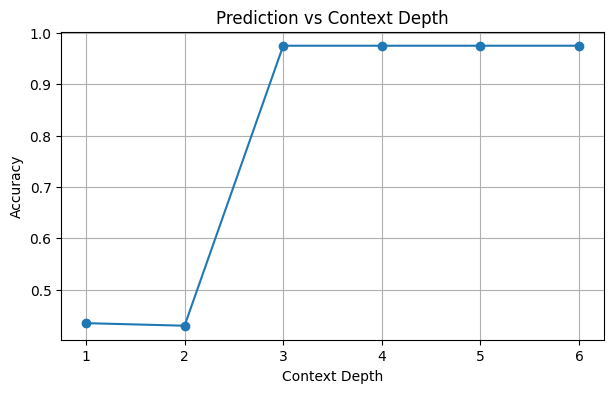

In [10]:
depths=[1,2,3,4,5,6]
scores=[]

for d in depths:
    t=ContextTree(max_depth=d)
    hist=[]
    c=0
    for s in sequence:
        p0,p1=t.predict(hist)
        pred=0 if p0>=p1 else 1
        if pred==s:
            c+=1
        t.update(hist,s)
        hist.append(s)
    scores.append(c/len(sequence))

plt.figure(figsize=(7,4))
plt.plot(depths,scores,marker="o")
plt.xlabel("Context Depth")
plt.ylabel("Accuracy")
plt.grid()
plt.title("Prediction vs Context Depth")
plt.show()


# Summary

This notebook introduced several ideas behind **MC-AIXI-CTW**:

- Variable-order contexts
- Online probability estimation
- Compression-inspired prediction
- Entropy
- Information gain
- Adaptive sequence learning

While simplified, these components illustrate why CTW is an effective
predictive model for agents operating in unknown environments.

## Notebook 5

The final notebook will integrate:

- Bayesian beliefs
- Universal mixtures
- CTW predictor
- Monte Carlo planning
- Multi-environment benchmarks
- An educational MC-AIXI-style agent
